# Homework 2 - Machine Learning for Regression · ML Zoomcamp 2026

**Dataset:** `car_fuel_efficiency_2026.csv` — pinned release from the course
repository (`cohorts/2026/data/`).

**Goal:** build a linear regression model that predicts car fuel efficiency
(`fuel_efficiency_mpg`).

Questions **Q1–Q6**. At the end: **Answers Summary** table (to copy into the
submission form) plus a self-verification cell.

Submission form: <https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the dataset

We use the pinned local copy from the course repository when it exists
(offline and deterministic), and fall back to the official homework URL.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp"
    "/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
)
CANDIDATES = [
    Path("cohorts/2026/data/car_fuel_efficiency_2026.csv"),       # cwd = repo root
    Path("../../cohorts/2026/data/car_fuel_efficiency_2026.csv"),  # cwd = 02-regression/hw2
    Path("machine-learning-zoomcamp/cohorts/2026/data/car_fuel_efficiency_2026.csv"),
]

_local = next((p for p in CANDIDATES if p.exists()), None)
source = _local if _local is not None else DATA_URL

df = pd.read_csv(source)
print("Source:", source)
print("Shape:", df.shape)
df.head()

Source: https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Shape: (10000, 11)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## Preparing the dataset

Use only these columns:

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`
* `'fuel_efficiency_mpg'`

The column names in this release are already lowercase with underscores, so the
`str.lower().str.replace(' ', '_')` normalization from the lessons is not needed.

In [3]:
FEATURES = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
TARGET = 'fuel_efficiency_mpg'
COLUMNS = FEATURES + [TARGET]

df = df[COLUMNS]

print("Shape after filtering:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape after filtering: (10000, 5)
Columns: ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## Exploratory data analysis

**Does `fuel_efficiency_mpg` have a long tail?**

Long-tail distributions confuse linear regression: because the model minimises
*squared* errors, a few extreme values dominate the fit. From the lessons, the
remedy is `np.log1p` (i.e. `log(1 + x)`) on the target variable.

In [4]:
target_raw = df[TARGET]

skew_raw = target_raw.skew()
skew_log = np.log1p(target_raw).skew()

print(f"Skewness raw target  : {skew_raw:.4f}")
print(f"Skewness after log1p : {skew_log:.4f}")
print()
print("Quantiles of the raw target:")
print(target_raw.quantile([0.5, 0.9, 0.99, 1.0]).to_string())
print()
print(f"Mean {target_raw.mean():.3f}  vs  Median {target_raw.median():.3f}")

has_long_tail = bool(skew_raw > 1)
print()
print("Long tail?", has_long_tail, "->",
      "YES, the distribution is right-skewed" if has_long_tail else "NO")

Skewness raw target  : 0.0808
Skewness after log1p : -0.1969

Quantiles of the raw target:
0.50    30.0
0.90    33.8
0.99    36.9
1.00    41.2

Mean 29.998  vs  Median 30.000

Long tail? False -> NO


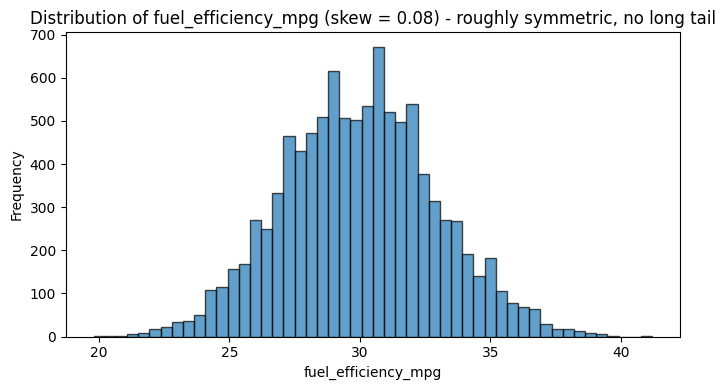

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(target_raw, bins=50, color="tab:blue", edgecolor="black", alpha=0.7)
ax.set_xlabel(TARGET)
ax.set_ylabel("Frequency")
ax.set_title(
    f"Distribution of {TARGET} (skew = {skew_raw:.2f}) - roughly symmetric, no long tail"
)

plt.tight_layout()
plt.show()

**Conclusion: this release does NOT have a long tail.** The skewness is close to 0
(~0.08) and the mean is very close to the median, so the distribution is roughly
symmetric rather than right-skewed.

In the car-price lecture the target had a long tail and `np.log1p` was applied to
the target. Here that is **not** needed - and applying it anyway would change the
scale of the target and produce RMSE values on a different scale. So we regress on
the **raw MPG values**.

## Setting up the validation framework

60% train / 20% validation / 20% test. We shuffle the indices first (the raw file
is grouped, so a sequential split would leak that structure), and we set
`np.random.seed(...)` so the split is reproducible.

Note `n_train` is computed as the remainder, so rounding never drops rows.

In [6]:
def split_data(df, seed):
    # 60/20/20 split, exactly as in the lectures
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test


def target(df_part):
    # Raw MPG target for a split. The EDA shows NO long tail in this release
    # (skew ~ 0.08), so - unlike the car-price lecture - we do NOT apply log1p.
    return df_part[TARGET].to_numpy(dtype=float)


def prepare_X(df_part, hp_fill=0.0):
    # Feature matrix; hp_fill is the value used for missing horsepower
    X = df_part[FEATURES].copy()
    X['horsepower'] = X['horsepower'].fillna(hp_fill)
    return X.to_numpy(dtype=float)


def train_linear_regression(X, y):
    # Normal equation: w = (X^T X)^-1 X^T y, with a ones column for the bias
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]


def train_linear_regression_reg(X, y, r=0.0):
    # Ridge regression: add r to the diagonal of the Gram matrix
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]


def rmse(y, y_pred):
    return float(np.sqrt(np.mean((y - y_pred) ** 2)))


print("Helpers defined.")

Helpers defined.


In [7]:
df_train, df_val, df_test = split_data(df, seed=42)

print("Train/Val/Test sizes:", len(df_train), len(df_val), len(df_test))
print("Missing horsepower per split:",
      int(df_train['horsepower'].isnull().sum()),
      int(df_val['horsepower'].isnull().sum()),
      int(df_test['horsepower'].isnull().sum()))

Train/Val/Test sizes: 6000 2000 2000
Missing horsepower per split: 538 176 163


## Question 1

**There's one column with missing values. What is it?**

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`

In [8]:
na_counts = df[FEATURES].isnull().sum()
print(na_counts.to_string())
print()

columns_with_na = list(na_counts[na_counts > 0].index)
answer_q1 = columns_with_na[0] if len(columns_with_na) == 1 else None

print("Columns with missing values:", columns_with_na)
print("Answer Q1:", answer_q1)

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0

Columns with missing values: ['horsepower']
Answer Q1: horsepower


## Question 2

**What's the median (50% percentile) for variable `'horsepower'`?**

* 204
* 254
* 304
* 354

In [9]:
answer_q2 = df['horsepower'].median()
print("Median horsepower:", answer_q2)
print("Answer Q2:", answer_q2)

Median horsepower: 254.0
Answer Q2: 254.0


## Question 3

* Fill the missing values with **0** or with the **mean** of the variable.
* Train a linear regression **without regularization** for each option.
* For the mean, use **the training data only** (using the full dataset would leak
  validation information into training).
* Evaluate on the validation set and compare RMSE, rounded to 3 decimals.

Which option gives better RMSE?

In [10]:
# NOTE: the mean is computed on df_train ONLY - never on the whole dataset.
hp_mean_train = df_train['horsepower'].mean()
print("Mean horsepower (train only):", hp_mean_train)
print()

q3_scores = {}
for strategy, fill in [("zero", 0.0), ("mean", hp_mean_train)]:
    X_train = prepare_X(df_train, hp_fill=fill)
    X_val = prepare_X(df_val, hp_fill=fill)

    w0, w = train_linear_regression(X_train, target(df_train))
    y_pred = w0 + X_val.dot(w)

    score = rmse(target(df_val), y_pred)
    q3_scores[strategy] = score
    print(f"fill={strategy:5s} -> RMSE = {score:.4f}  (rounded: {round(score, 3)})")

best_q3 = min(q3_scores, key=q3_scores.get)
if round(q3_scores["zero"], 3) == round(q3_scores["mean"], 3):
    answer_q3 = "Both are equally good"
else:
    answer_q3 = "With mean" if best_q3 == "mean" else "With 0"

print()
print("Answer Q3:", answer_q3)

Mean horsepower (train only): 254.46338337605272

fill=zero  -> RMSE = 2.2053  (rounded: 2.205)
fill=mean  -> RMSE = 2.2018  (rounded: 2.202)

Answer Q3: With mean


## Question 4

* Fill the NAs with **0**.
* Train a **regularized** linear regression for `r` in `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Evaluate with RMSE on the validation dataset, rounded to 4 decimals.

Which `r` gives the best RMSE? (ties -> smallest `r`)

In [11]:
X_train = prepare_X(df_train, hp_fill=0.0)
X_val = prepare_X(df_val, hp_fill=0.0)
y_train = target(df_train)
y_val = target(df_val)

q4_scores = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    score = rmse(y_val, w0 + X_val.dot(w))
    q4_scores[r] = round(score, 4)
    print(f"r = {r:<6} RMSE = {score:.6f}  (rounded: {round(score, 4)})")

# ties -> smallest r
answer_q4 = min(q4_scores, key=lambda k: (q4_scores[k], k))

print()
print("Answer Q4: r =", answer_q4)

r = 0      RMSE = 2.205293  (rounded: 2.2053)
r = 0.01   RMSE = 2.205828  (rounded: 2.2058)
r = 0.1    RMSE = 2.224143  (rounded: 2.2241)
r = 1      RMSE = 2.349229  (rounded: 2.3492)
r = 5      RMSE = 2.409380  (rounded: 2.4094)
r = 10     RMSE = 2.419470  (rounded: 2.4195)
r = 100    RMSE = 2.429202  (rounded: 2.4292)

Answer Q4: r = 0


## Question 5

* Repeat the 60/20/20 split with seeds `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* Fill missing values with **0**, train **without regularization**.
* Evaluate on validation for each seed and collect the RMSE scores.
* What's the standard deviation (`np.std`) of all the scores, rounded to 3 decimals?

A low std means the model is **stable** across different splits.

In [12]:
q5_scores = []
for seed in range(10):
    tr, va, _ = split_data(df, seed=seed)

    X_tr = prepare_X(tr, hp_fill=0.0)
    X_va = prepare_X(va, hp_fill=0.0)

    w0, w = train_linear_regression(X_tr, target(tr))
    score = rmse(target(va), w0 + X_va.dot(w))

    q5_scores.append(score)
    print(f"seed = {seed:<2} RMSE = {score:.4f}")

std = float(np.std(q5_scores))
answer_q5 = round(std, 3)

print()
print("All scores:", np.round(q5_scores, 4).tolist())
print(f"np.std(scores) = {std:.6f}  -> rounded: {answer_q5}")
print("Answer Q5:", answer_q5)

seed = 0  RMSE = 2.2392
seed = 1  RMSE = 2.2021
seed = 2  RMSE = 2.1634
seed = 3  RMSE = 2.2044
seed = 4  RMSE = 2.2019
seed = 5  RMSE = 2.2458
seed = 6  RMSE = 2.2697
seed = 7  RMSE = 2.1908
seed = 8  RMSE = 2.2166
seed = 9  RMSE = 2.2070

All scores: [2.2392, 2.2021, 2.1634, 2.2044, 2.2019, 2.2458, 2.2697, 2.1908, 2.2166, 2.207]
np.std(scores) = 0.028781  -> rounded: 0.029
Answer Q5: 0.029


## Question 6

* Split the dataset as before, using **seed 9**.
* **Combine train and validation** datasets.
* Fill missing values with **0** and train with `r = 0.001`.
* What's the RMSE on the **test** dataset?

Rationale: once `r` has been chosen on validation, the validation set has done its
job - we recycle it into training (more data), and the test set stays untouched as
an honest final evaluation.

In [13]:
tr9, va9, te9 = split_data(df, seed=9)

train_val = pd.concat([tr9, va9])

X_train_val = prepare_X(train_val, hp_fill=0.0)
X_test = prepare_X(te9, hp_fill=0.0)
w0, w = train_linear_regression_reg(X_train_val, target(train_val), r=0.001)
y_pred_test = w0 + X_test.dot(w)

q6_rmse = rmse(target(te9), y_pred_test)
answer_q6 = round(q6_rmse, 3)

print("Train+val rows:", len(train_val), "| Test rows:", len(te9))
print(f"Test RMSE = {q6_rmse:.6f}  (rounded: {answer_q6})")
print("Answer Q6:", answer_q6)

Train+val rows: 8000 | Test rows: 2000
Test RMSE = 2.235828  (rounded: 2.236)
Answer Q6: 2.236


## Self-verification

Every answer is re-checked against the exact option lists given in the homework.

In [14]:
Q1_OPTIONS = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
Q2_OPTIONS = [204, 254, 304, 354]
Q3_OPTIONS = ['With 0', 'With mean', 'Both are equally good']
Q4_OPTIONS = [0, 0.01, 0.1, 1, 5, 10, 100]
Q5_OPTIONS = [0.006, 0.016, 0.029, 0.036]
Q6_OPTIONS = [0.236, 2.236, 22.10, 221.0]

# Q1 - exactly one column with NAs, and it is the one we report
assert len(columns_with_na) == 1, columns_with_na
assert answer_q1 in Q1_OPTIONS, answer_q1
assert na_counts[answer_q1] > 0

# Q2 - must match an offered option
assert answer_q2 in Q2_OPTIONS, answer_q2
assert answer_q2 == df['horsepower'].median()

# Q3 - the reported option must genuinely be the lowest rounded RMSE
assert answer_q3 in Q3_OPTIONS, answer_q3
assert set(q3_scores) == {"zero", "mean"}
if answer_q3 != "Both are equally good":
    assert q3_scores[answer_q3.split()[-1].lower()] == min(q3_scores.values())

# Q4 - best r, ties broken by smallest r
assert answer_q4 in Q4_OPTIONS, answer_q4
assert q4_scores[answer_q4] == min(q4_scores.values())
assert answer_q4 == min(q4_scores, key=lambda k: (q4_scores[k], k))

# Q5 - 10 seeds, std matches, and lands on an offered option
assert len(q5_scores) == 10, len(q5_scores)
assert answer_q5 == round(float(np.std(q5_scores)), 3), answer_q5
assert answer_q5 in Q5_OPTIONS, answer_q5

# Q6 - test RMSE must match an offered option
assert answer_q6 in Q6_OPTIONS, answer_q6
assert answer_q6 == round(q6_rmse, 3), (answer_q6, q6_rmse)

print("OK: all answers verified")

OK: all answers verified


## Answers Summary

| Question | Description | Answer |
|---|---|---|
| **Q1** | Column with missing values | `horsepower` |
| **Q2** | Median of `horsepower` | `254` |
| **Q3** | Better imputation: 0 vs mean | `With mean` |
| **Q4** | Best `r` | `0` |
| **Q5** | `np.std` of the 10 validation RMSE scores | `0.029` |
| **Q6** | Test RMSE (seed 9, train+val, `r=0.001`) | `2.236` |

These values are computed and asserted in the cells above; the same table is
written to `hw2.md` next to this notebook.

> The EDA shows **no long tail** in this release, so the target is the **raw**
> `fuel_efficiency_mpg` (no `log1p`) and **all RMSE values are in MPG**.

In [15]:
summary = pd.DataFrame(
    [
        ["Q1", "Column with missing values", answer_q1],
        ["Q2", "Median of 'horsepower'", answer_q2],
        ["Q3", "Better RMSE: 0 vs mean", answer_q3],
        ["Q4", "Best r", answer_q4],
        ["Q5", "std of validation RMSE (10 seeds)", answer_q5],
        ["Q6", "Test RMSE (seed 9, r=0.001)", answer_q6],
    ],
    columns=["Question", "Description", "Answer"],
)
summary

,Question,Description,Answer
0,Q1,Column with missing values,horsepower
1,Q2,Median of 'horsepower',254.0
2,Q3,Better RMSE: 0 vs mean,With mean
3,Q4,Best r,0
4,Q5,std of validation RMSE (10 seeds),0.029
5,Q6,"Test RMSE (seed 9, r=0.001)",2.236
